# 02 Baseline Logistic Regression

This notebook trains a first-pass fraud classifier using the reusable pipeline in `src/` and evaluates it with metrics that are actually useful for an imbalanced fraud problem.

The main goals here are:

- establish a transparent baseline before trying stronger models
- inspect `ROC` and `PR` behavior instead of relying on accuracy
- compare operating thresholds rather than assuming `0.5` is the right cutoff
- measure how much fraud we can capture in the top-risk slice of transactions


In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import HTML, display
from sklearn.metrics import confusion_matrix

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.fraud_detection.eda import PLOT_COLORS, metric_cards_html, set_plot_theme
from src.fraud_detection.metrics import build_curve_frames
from src.fraud_detection.train import fit_baseline_experiment

warnings.filterwarnings("ignore")
set_plot_theme()
pd.set_option("display.max_columns", 120)
sns.set_context("talk")

SAMPLE_SIZE = 50_000
MISSING_THRESHOLD = 0.95
RANDOM_STATE = 42


In [2]:
experiment = fit_baseline_experiment(
    sample_size=SAMPLE_SIZE,
    missing_threshold=MISSING_THRESHOLD,
    random_state=RANDOM_STATE,
)

metrics = experiment["metrics"]
threshold_table = experiment["threshold_table"].copy()
curve_frames = build_curve_frames(experiment["y_valid"], experiment["validation_scores"])
best_f1_row = threshold_table.sort_values("f1", ascending=False).iloc[0]

y_valid = np.asarray(experiment["y_valid"])
validation_scores = np.asarray(experiment["validation_scores"])
y_pred_default = (validation_scores >= 0.5).astype(int)
cm = confusion_matrix(y_valid, y_pred_default, labels=[0, 1], normalize="true")

score_frame = pd.DataFrame(
    {
        "score": validation_scores,
        "Class": np.where(y_valid == 1, "Fraud", "Legitimate"),
    }
)

run_summary = pd.DataFrame(
    [
        {"item": "Sample size", "value": f"{SAMPLE_SIZE:,} rows"},
        {"item": "Train rows", "value": f"{len(experiment['x_train']):,}"},
        {"item": "Validation rows", "value": f"{len(experiment['x_valid']):,}"},
        {"item": "Dropped high-missing columns", "value": f"{len(experiment['dropped_high_missing_columns']):,}"},
        {"item": "Numeric features", "value": f"{len(experiment['numeric_features']):,}"},
        {"item": "Categorical features", "value": f"{len(experiment['categorical_features']):,}"},
    ]
)

top_risk_table = pd.DataFrame(
    [
        {
            "slice": "Top 1% scores",
            "precision": metrics["precision_at_top_1pct"],
            "recall": metrics["recall_at_top_1pct"],
            "lift": metrics["lift_at_top_1pct"],
        },
        {
            "slice": "Top 5% scores",
            "precision": metrics["precision_at_top_5pct"],
            "recall": metrics["recall_at_top_5pct"],
            "lift": metrics["lift_at_top_5pct"],
        },
    ]
)

print("Baseline fit complete.")
print(f"Validation ROC-AUC: {metrics['roc_auc']:.4f}")
print(f"Validation PR-AUC (Average Precision): {metrics['average_precision']:.4f}")


Baseline fit complete.
Validation ROC-AUC: 0.8245
Validation PR-AUC (Average Precision): 0.3998


## Baseline Snapshot

For an imbalanced fraud problem, a baseline is only useful if it answers two questions:

1. **How well does the model rank risky transactions overall?**
2. **How much fraud can we capture when we only act on the highest-risk slice?**

That is why this notebook emphasizes `PR-AUC`, `ROC-AUC`, threshold tradeoffs, and top-risk capture metrics.


In [3]:
cards = [
    {
        "title": "ROC-AUC",
        "value": f"{metrics['roc_auc']:.3f}",
        "subtitle": "overall ranking quality",
    },
    {
        "title": "PR-AUC",
        "value": f"{metrics['average_precision']:.3f}",
        "subtitle": "average precision on an imbalanced target",
    },
    {
        "title": "Recall @ 0.5",
        "value": f"{metrics['recall']:.1%}",
        "subtitle": "default threshold sensitivity",
    },
    {
        "title": "Recall @ Top 5%",
        "value": f"{metrics['recall_at_top_5pct']:.1%}",
        "subtitle": "fraud captured in highest-risk 5%",
    },
    {
        "title": "Precision @ Top 1%",
        "value": f"{metrics['precision_at_top_1pct']:.1%}",
        "subtitle": "purity of the top-ranked slice",
    },
    {
        "title": "Best F1 Threshold",
        "value": f"{best_f1_row['threshold']:.2f}",
        "subtitle": "best threshold inside the notebook sweep",
    },
]

display(HTML(metric_cards_html(cards)))

display(run_summary.style.hide(axis="index"))

display(
    top_risk_table.style
    .format({"precision": "{:.2%}", "recall": "{:.2%}", "lift": "{:.2f}x"})
    .hide(axis="index")
)


item,value
Sample size,"50,000 rows"
Train rows,"40,000"
Validation rows,"10,000"
Dropped high-missing columns,9
Numeric features,394
Categorical features,29


slice,precision,recall,lift
Top 1% scores,74.00%,20.61%,20.61x
Top 5% scores,32.80%,45.68%,9.14x


## Core Curves And Threshold Tradeoffs

`ROC` can look optimistic on imbalanced data, so we keep it but do not treat it as the only decision metric. `PR` is more revealing because it directly exposes the precision-recall tradeoff on the fraud class.


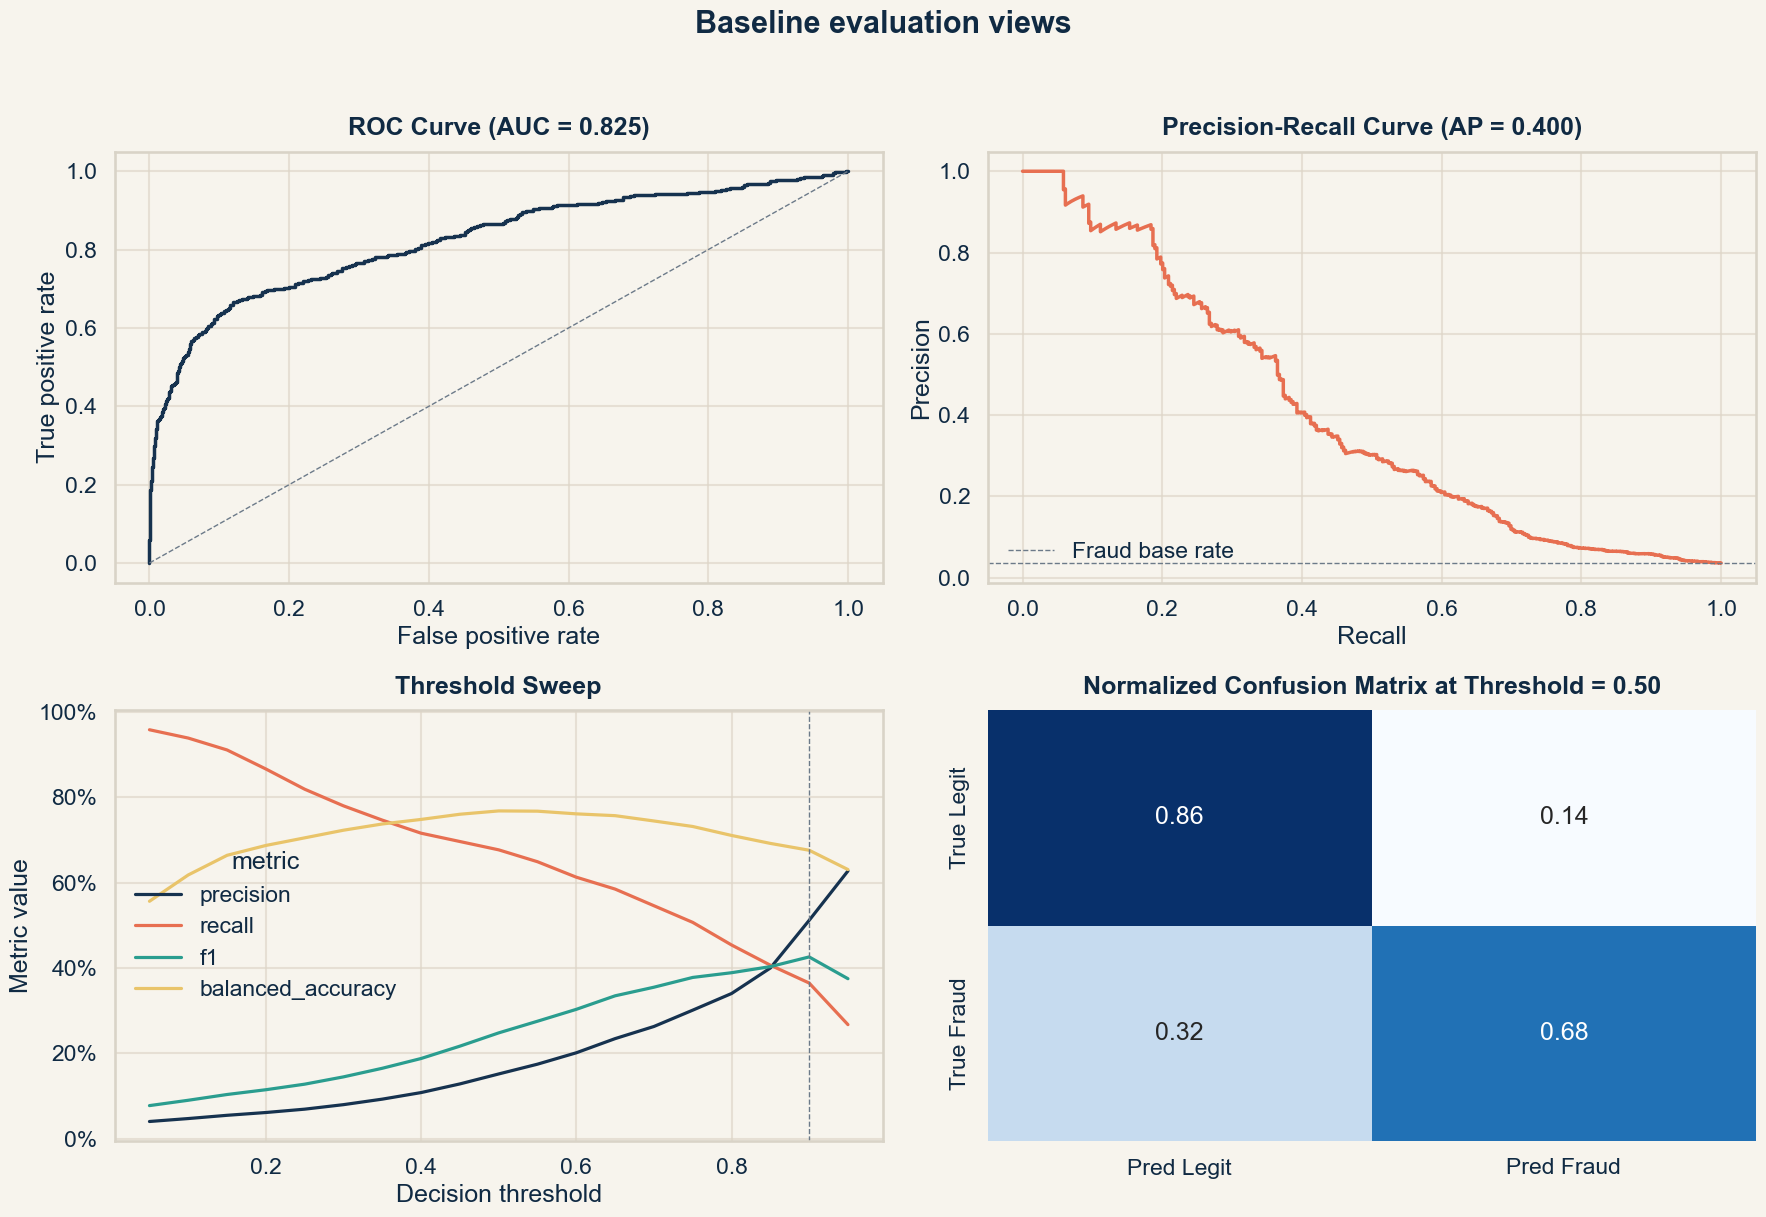

In [4]:
threshold_plot = threshold_table.melt(
    id_vars="threshold",
    value_vars=["precision", "recall", "f1", "balanced_accuracy"],
    var_name="metric",
    value_name="value",
)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

axes[0, 0].plot(curve_frames["roc"]["fpr"], curve_frames["roc"]["tpr"], color=PLOT_COLORS["navy"], linewidth=2.5)
axes[0, 0].plot([0, 1], [0, 1], linestyle="--", color=PLOT_COLORS["muted"], linewidth=1)
axes[0, 0].set_title(f"ROC Curve (AUC = {metrics['roc_auc']:.3f})")
axes[0, 0].set_xlabel("False positive rate")
axes[0, 0].set_ylabel("True positive rate")

axes[0, 1].plot(curve_frames["pr"]["recall"], curve_frames["pr"]["precision"], color=PLOT_COLORS["coral"], linewidth=2.5)
axes[0, 1].axhline(metrics["base_fraud_rate"], linestyle="--", color=PLOT_COLORS["muted"], linewidth=1, label="Fraud base rate")
axes[0, 1].set_title(f"Precision-Recall Curve (AP = {metrics['average_precision']:.3f})")
axes[0, 1].set_xlabel("Recall")
axes[0, 1].set_ylabel("Precision")
axes[0, 1].legend(loc="lower left")

sns.lineplot(
    data=threshold_plot,
    x="threshold",
    y="value",
    hue="metric",
    palette=[PLOT_COLORS["navy"], PLOT_COLORS["coral"], PLOT_COLORS["teal"], PLOT_COLORS["gold"]],
    linewidth=2.3,
    ax=axes[1, 0],
)
axes[1, 0].axvline(best_f1_row["threshold"], linestyle="--", color=PLOT_COLORS["muted"], linewidth=1)
axes[1, 0].set_title("Threshold Sweep")
axes[1, 0].set_xlabel("Decision threshold")
axes[1, 0].set_ylabel("Metric value")
axes[1, 0].yaxis.set_major_formatter(PercentFormatter(1))

sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=False,
    xticklabels=["Pred Legit", "Pred Fraud"],
    yticklabels=["True Legit", "True Fraud"],
    ax=axes[1, 1],
)
axes[1, 1].set_title("Normalized Confusion Matrix at Threshold = 0.50")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("")

plt.suptitle("Baseline evaluation views", fontsize=22, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## Score Separation

The score distributions below help us see whether the logistic model is meaningfully separating fraud from legitimate traffic, even if the two classes still overlap.


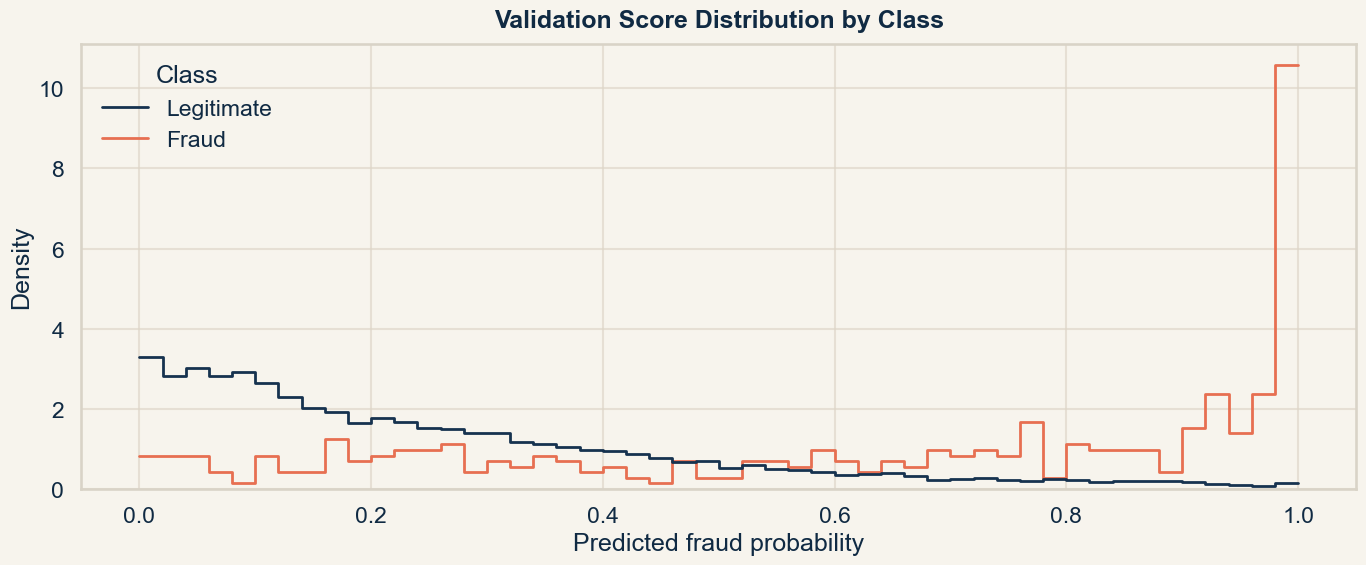

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.histplot(
    data=score_frame,
    x="score",
    hue="Class",
    bins=50,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    linewidth=2,
    palette=[PLOT_COLORS["navy"], PLOT_COLORS["coral"]],
    ax=ax,
)
ax.set_title("Validation Score Distribution by Class")
ax.set_xlabel("Predicted fraud probability")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()


## Threshold Table

The threshold sweep is useful because the default cutoff of `0.5` is rarely the best operating point for fraud detection. We usually care about a tradeoff between review capacity, recall, and alert precision.


In [6]:
display(
    threshold_table.style
    .format(
        {
            "threshold": "{:.2f}",
            "roc_auc": "{:.3f}",
            "average_precision": "{:.3f}",
            "log_loss": "{:.3f}",
            "brier_score": "{:.3f}",
            "precision": "{:.2%}",
            "recall": "{:.2%}",
            "f1": "{:.2%}",
            "balanced_accuracy": "{:.2%}",
            "positive_prediction_rate": "{:.2%}",
            "base_fraud_rate": "{:.2%}",
        }
    )
    .hide(axis="index")
)


threshold,roc_auc,average_precision,log_loss,brier_score,precision,recall,f1,balanced_accuracy,positive_prediction_rate,base_fraud_rate
0.05,0.825,0.400,0.393,0.118,4.05%,95.82%,7.77%,55.64%,84.95%,3.59%
0.10,0.825,0.400,0.393,0.118,4.74%,93.87%,9.02%,61.81%,71.10%,3.59%
0.15,0.825,0.400,0.393,0.118,5.50%,91.09%,10.37%,66.41%,59.45%,3.59%
0.20,0.825,0.400,0.393,0.118,6.15%,86.63%,11.49%,68.72%,50.54%,3.59%
0.25,0.825,0.400,0.393,0.118,6.94%,81.89%,12.79%,70.50%,42.37%,3.59%
0.30,0.825,0.400,0.393,0.118,8.00%,77.99%,14.50%,72.29%,35.02%,3.59%
0.35,0.825,0.400,0.393,0.118,9.29%,74.65%,16.52%,73.75%,28.86%,3.59%
0.40,0.825,0.400,0.393,0.118,10.83%,71.59%,18.81%,74.81%,23.74%,3.59%
0.45,0.825,0.400,0.393,0.118,12.85%,69.64%,21.70%,76.03%,19.45%,3.59%
0.50,0.825,0.400,0.393,0.118,15.19%,67.69%,24.81%,76.81%,16.00%,3.59%


## Recommended Metric Set

For the rest of this project, a good metric stack is:

- **Primary ranking metric:** `PR-AUC` / average precision
- **Secondary ranking metric:** `ROC-AUC`
- **Threshold metrics:** precision, recall, F1, and balanced accuracy at a chosen cutoff
- **Operational metrics:** recall and precision in the top-risk slice, such as top `1%` and top `5%`

This gives us both a model-comparison view and an operations-facing view. It also sets up a clean transition to tree-based models, where we can reuse the exact same evaluation lenses.
